get the data


In [1]:
import os
os.chdir('/home/cyf/wbi/Virginia/code/wbi_0123/wholistic_registration/src/wholistic_registration')
import cupy as cp
cp.cuda.Device(1).use()
from utils import IO
from utils import calFlowCrossResolution, calFlow3d_Wei_v1
from utils import registration
from utils import option
from utils import preprocess as prep
from utils import mask
from utils import  visualization
import numpy as np
gut_mov_Path     = "/home/cyf/wbi/Virginia/registrated_data/f260201/gut/raw/260201_test1_0_00002_TZCXY.ome.tif"
ventral_mov_Path = "/home/cyf/wbi/Virginia/registrated_data/f260201/ventral/raw/260201_test1_0_00003_TZCXY.ome.tif"
dorsal_mov_Path  = "/home/cyf/wbi/Virginia/registrated_data/f260201/dorsal/raw/260201_test1_0_00005_TZCXY.ome.tif"
gut_ref_Path     = "/home/cyf/wbi/Virginia/registrated_data/f260201/gut/anat/260201_test1_0_00002_TZCXY.ome.tif"
ventral_ref_Path = "/home/cyf/wbi/Virginia/registrated_data/f260201/ventral/anat/260201_test1_0_00002_TZCXY.ome.tif"
dorsal_ref_Path  = "/home/cyf/wbi/Virginia/registrated_data/f260201/dorsal/anat/260201_test1_0_00004_TZCXY.ome.tif"

CuPy is available with CUDA - using GPU acceleration


gut exp
---

In [1]:
gut_ref,gut_ref_desc = IO.readTifff(gut_ref_Path)
gut_mov,gut_mov_desc = IO.readTifff(gut_mov_Path)

gut_ref = gut_ref.transpose(1,2,0)
gut_mov = gut_mov.transpose(0,2,3,1)
### see the slice 86, 87,88
### use the whole image as the groundtruth
#initial the pyramid parameters
for frame in range(0,5):
    gut_ref_sample = gut_ref[...,40:120]
    gut_mov_sample = gut_mov[frame,:,:,40:120]
    print(gut_ref_sample.shape)
    print(gut_mov_sample.shape)
    from skimage.exposure import match_histograms
    gut_mov_sample = match_histograms(gut_mov_sample, gut_ref_sample)
    # visualization.visualize_2d_image(gut_mov_sample[...,slice],title = "moving image")
    # visualization.visualize_2d_image(gut_ref_sample[...,slice],title = "reference image")
    slice = 39
    option['motion']=np.zeros([gut_ref_sample.shape[0],gut_ref_sample.shape[1],gut_ref_sample.shape[2],3])
    option['r']=5
    option['layer']=2
    option['iter']=10
    option['movRange']=5.
    option['tol']=1e-6
    thresFactor= 5.
    maskRange  = [5.,4000.]
    smoothPenalty_raw=0.03

    option['mask_ref']=mask.getMask(gut_ref_sample,thresFactor)
    option['mask_ref']=mask.bwareafilt3_wei(option['mask_ref'],maskRange)
    option['mask_mov']=mask.getMask(gut_mov_sample,thresFactor)
    option['mask_mov']=mask.bwareafilt3_wei(option['mask_mov'],maskRange)

    print(option['mask_ref'].shape)
    Pnltfactor = prep.getSmPnltNormFctr(gut_ref_sample, option)
    smoothPenalty=Pnltfactor*smoothPenalty_raw
    option['smoothPenalty']=smoothPenalty
    option['zRatio'] = 20

    # motion_current, _ , new_coords,error_logs = calFlow3d_Wei_v1.getMotion(gut_mov_sample, gut_ref_sample,option,verbose = True)
    # corrected_mem = calFlow3d_Wei_v1.correctMotion(gut_mov_sample, motion_current)
    # visualization.visualize_2d_image(corrected_mem[...,47],title = "corrected image")

    gut_single_plane = gut_mov_sample[:,:,slice:slice+1]
    option['zRatio_HR']= 20

    H, W, D = gut_single_plane.shape
    X, Y, Z = np.indices((H, W, D))

    # phase_init = np.stack([
    #     X.astype(np.float32),
    #     Y.astype(np.float32),
    #     (slice + Z * option["zRatio"] / option["zRatio_HR"]).astype(np.float32)
    # ], axis=-1)
    phase_init, z_init = calFlowCrossResolution.FindInitPhase(gut_single_plane,gut_ref_sample,64,return_debug = False)

    print(phase_init.shape)
    option["phase"] = np.array(phase_init)

#     phase_new,motion_current,data_mov_mapped= calFlowCrossResolution.getMotion(gut_single_plane, gut_ref_sample,option,verbose = True)
#     # visualization.visualize_2d_image(data_mov_mapped.get(),title = "mapped image")
#     IO.write_multichannel_volume_as_ome_tiff(
#             volume=[data_mov_mapped.get().squeeze(),gut_mov_sample[...,slice],gut_ref_sample[...,slice],corrected_mem[...,slice]],      # single channel
#             out_dir="/home/cyf/wbi/Virginia/HR_exp/",
#             frame_idx= frame,
#             label=f'Gut_HR_S{slice+40}_optiInit'
#     )

NameError: name 'IO' is not defined

(1086, 538, 80)
(1086, 538, 80)
(1086, 538, 80)

========== start layer 3/3 ==========
[layer=3] iter=00 error=28051.6640 diff=28051.6640 penalty=0.0000
[layer=3] iter=01 error=16955.0977 diff=16825.3076 penalty=129.7901
[layer=3] iter=02 error=14805.4640 diff=14513.2376 penalty=292.2264
[layer=3] iter=03 error=13391.3657 diff=12905.6442 penalty=485.7215
[layer=3] iter=04 error=12330.9929 diff=11664.3499 penalty=666.6430
[layer=3] iter=05 error=11502.8757 diff=10697.8245 penalty=805.0512
[layer=3] iter=06 error=10833.3472 diff=9921.8817 penalty=911.4655
[layer=3] iter=07 error=10300.6533 diff=9300.5348 penalty=1000.1185
[layer=3] iter=08 error=9860.5332 diff=8784.5043 penalty=1076.0289
[layer=3] iter=09 error=9493.7740 diff=8349.7070 penalty=1144.0670
[layer=3] detected wrong regions: 2
[layer=3] mask kept ratio after correction: 0.955
[layer=3] iter=00 error=27818.4594 diff=27818.4594 penalty=0.0000
[layer=3] iter=01 error=16773.8733 diff=16646.9733 penalty=126.9000
[layer=3] iter=02 

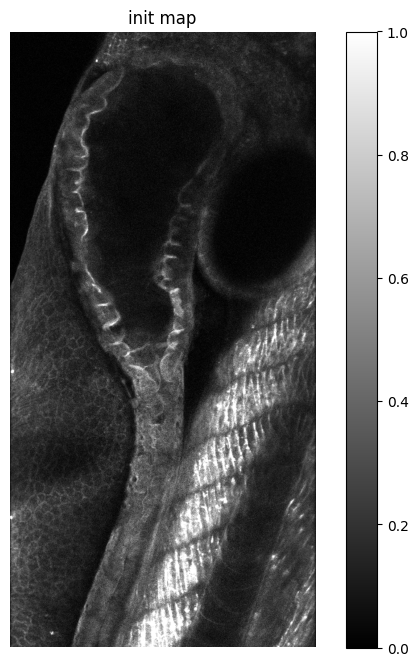

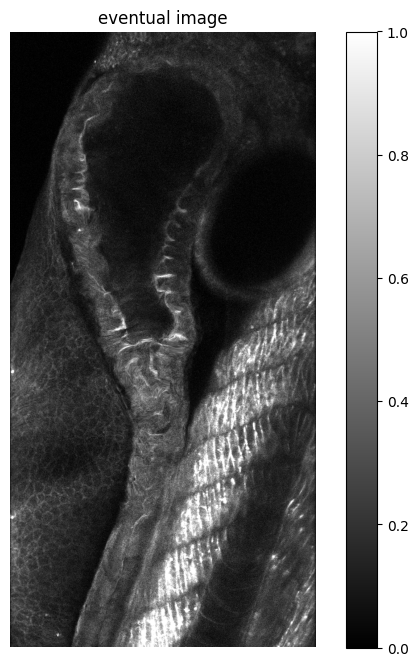

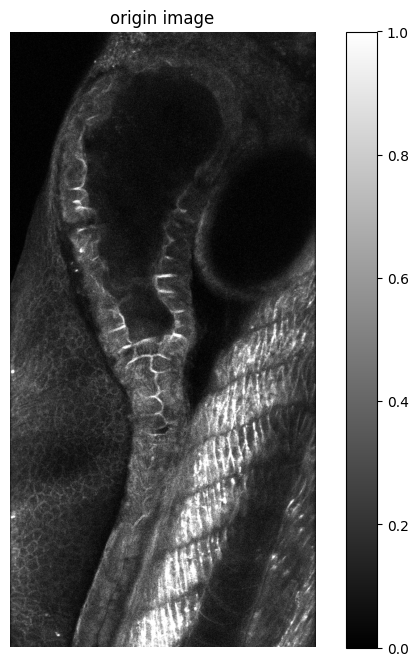

(1086, 538, 80)
(1086, 538, 80)
(1086, 538, 80)

========== start layer 3/3 ==========
[layer=3] iter=00 error=23269.1497 diff=23269.1497 penalty=0.0000
[layer=3] iter=01 error=12157.7285 diff=12071.3436 penalty=86.3849
[layer=3] iter=02 error=10046.0575 diff=9853.0861 penalty=192.9714
[layer=3] iter=03 error=8801.6904 diff=8499.7126 penalty=301.9778
[layer=3] iter=04 error=7981.1729 diff=7589.2938 penalty=391.8791
[layer=3] iter=05 error=7333.3337 diff=6865.5979 penalty=467.7357
[layer=3] iter=06 error=6807.0106 diff=6281.0720 penalty=525.9386
[layer=3] iter=07 error=6379.4211 diff=5801.8663 penalty=577.5548
[layer=3] iter=08 error=6031.7161 diff=5406.7410 penalty=624.9751
[layer=3] iter=09 error=5747.8210 diff=5078.2630 penalty=669.5580
[layer=3] detected wrong regions: 1
[layer=3] mask kept ratio after correction: 0.956
[layer=3] iter=00 error=22911.7312 diff=22911.7312 penalty=0.0000
[layer=3] iter=01 error=11795.6263 diff=11712.9107 penalty=82.7156
[layer=3] iter=02 error=9586.099

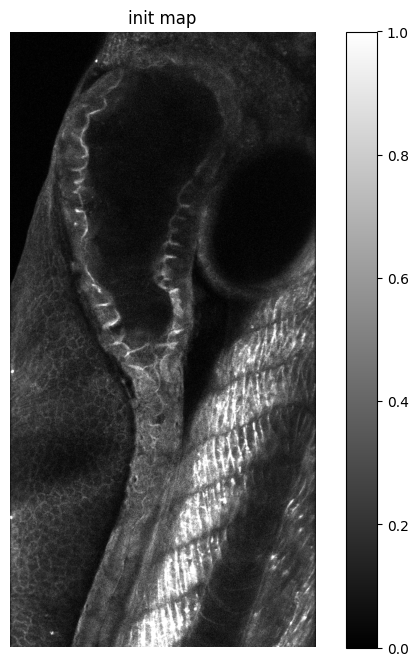

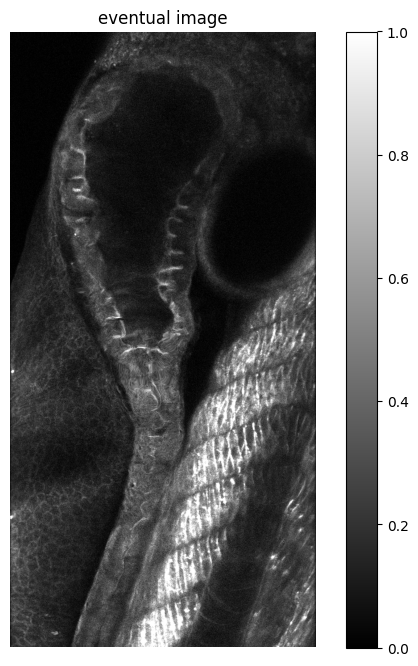

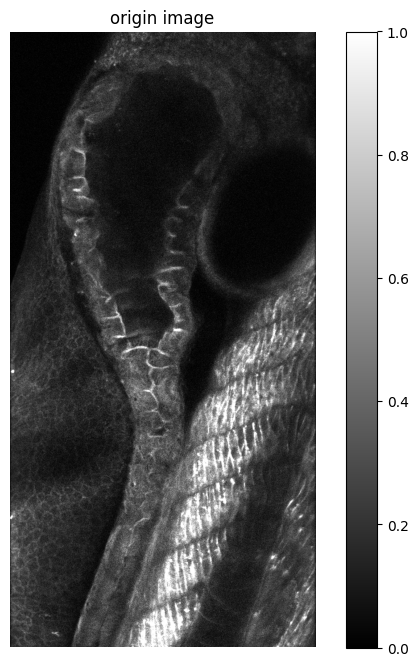

(1086, 538, 80)
(1086, 538, 80)
(1086, 538, 80)

========== start layer 3/3 ==========
[layer=3] iter=00 error=11481.1778 diff=11481.1778 penalty=0.0000
[layer=3] iter=01 error=1927.1710 diff=1914.9289 penalty=12.2421
[layer=3] iter=02 error=1217.8664 diff=1206.8238 penalty=11.0426
[layer=3] iter=03 error=951.1360 diff=940.4727 penalty=10.6633
[layer=3] iter=04 error=781.5001 diff=770.1961 penalty=11.3040
[layer=3] iter=05 error=656.0877 diff=643.6365 penalty=12.4512
[layer=3] iter=06 error=558.2586 diff=544.4567 penalty=13.8018
[layer=3] iter=07 error=479.9059 diff=464.6866 penalty=15.2192
[layer=3] iter=08 error=416.1157 diff=399.4757 penalty=16.6400
[layer=3] iter=09 error=363.6406 diff=345.6048 penalty=18.0358
[layer=3] detected wrong regions: 0

========== start layer 2/3 ==========
[layer=2] iter=00 error=11261.0232 diff=11258.8607 penalty=2.1625
[layer=2] iter=01 error=1413.1937 diff=1400.0101 penalty=13.1836
[layer=2] iter=02 error=545.5048 diff=533.7311 penalty=11.7737
[layer=

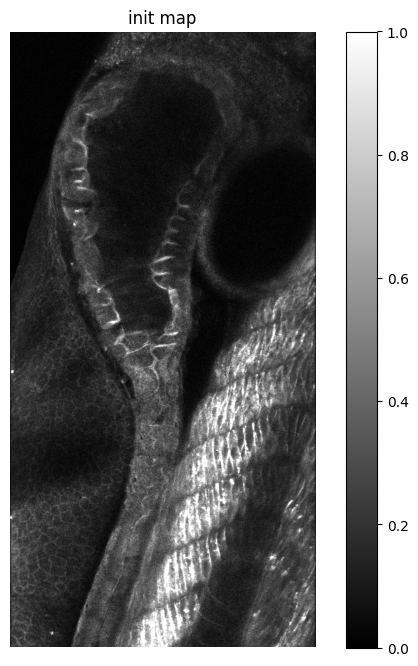

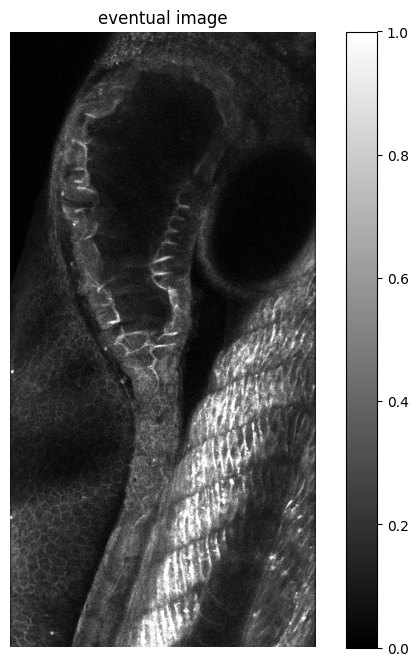

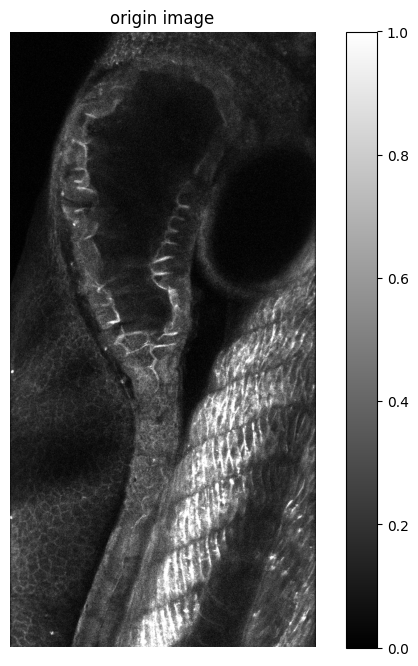

(1086, 538, 80)
(1086, 538, 80)
(1086, 538, 80)

========== start layer 3/3 ==========
[layer=3] iter=00 error=27043.3822 diff=27043.3822 penalty=0.0000
[layer=3] iter=01 error=13528.7131 diff=13457.1436 penalty=71.5695
[layer=3] iter=02 error=11145.8505 diff=11007.5782 penalty=138.2723
[layer=3] iter=03 error=9739.0987 diff=9538.7378 penalty=200.3610
[layer=3] iter=04 error=8635.7653 diff=8376.7994 penalty=258.9660
[layer=3] iter=05 error=7701.5613 diff=7388.0587 penalty=313.5026
[layer=3] iter=06 error=6919.2496 diff=6547.6734 penalty=371.5762
[layer=3] iter=07 error=6267.3792 diff=5834.8469 penalty=432.5323
[layer=3] iter=08 error=5734.8945 diff=5240.4415 penalty=494.4530
[layer=3] iter=09 error=5303.4175 diff=4747.7614 penalty=555.6562
[layer=3] detected wrong regions: 1
[layer=3] mask kept ratio after correction: 0.978
[layer=3] iter=00 error=27018.1665 diff=27018.1665 penalty=0.0000
[layer=3] iter=01 error=13484.8619 diff=13413.2840 penalty=71.5779
[layer=3] iter=02 error=10980.0

In [ ]:
gut_ref,gut_ref_desc = IO.readTifff(gut_ref_Path)
gut_mov,gut_mov_desc = IO.readTifff(gut_mov_Path)
# print(gut_ref_desc)
gut_ref = gut_ref.transpose(1,2,0)
gut_mov = gut_mov.transpose(0,2,3,1)
### see the slice 86, 87,88
### use the whole image as the groundtruth
#initial the pyramid parameters
for frame in range(0,5):
    gut_ref_sample = gut_mov[2,:,:,40:120]
    gut_mov_sample = gut_mov[frame,:,:,40:120]
    print(gut_ref_sample.shape)
    print(gut_mov_sample.shape)
    from skimage.exposure import match_histograms
    gut_mov_sample = match_histograms(gut_mov_sample, gut_ref_sample)
    # visualization.visualize_2d_image(gut_mov_sample[...,slice],title = "moving image")
    # visualization.visualize_2d_image(gut_ref_sample[...,slice],title = "reference image")
    slice = 39
    option['motion']=np.zeros([gut_ref_sample.shape[0],gut_ref_sample.shape[1],gut_ref_sample.shape[2],3])
    option['r']=5
    option['layer']=3
    option['iter']=10
    option['movRange']=15.
    option['tol']=1e-6
    thresFactor= 5.
    maskRange  = [5.,4000.]
    smoothPenalty_raw=0.03

    option['mask_ref']=mask.getMask(gut_ref_sample,thresFactor)
    option['mask_ref']=mask.bwareafilt3_wei(option['mask_ref'],maskRange)
    option['mask_mov']=mask.getMask(gut_mov_sample,thresFactor)
    option['mask_mov']=mask.bwareafilt3_wei(option['mask_mov'],maskRange)

    print(option['mask_ref'].shape)
    Pnltfactor = prep.getSmPnltNormFctr(gut_ref_sample, option)
    smoothPenalty=Pnltfactor*smoothPenalty_raw
    option['smoothPenalty']=smoothPenalty
    option['zRatio'] =  1

    # motion_current, _ , new_coords,error_logs = calFlow3d_Wei_v1.getMotion(gut_ref_sample, gut_mov_sample,option,verbose = False)
    # corrected_mem = calFlow3d_Wei_v1.correctMotion(gut_ref_sample, motion_current)
    # visualization.visualize_2d_image(corrected_mem[...,47],title = "corrected image")
    # visualization.visualize_2d_image(gut_mov_sample[...,47],title = "raw image")
    gut_single_plane = gut_mov_sample[:,:,slice:slice+1]
    option['zRatio_HR']= 1

    option["wrong_region_enable"] = True
    option["wrong_region_metric"] = "mae"
    option["wrong_region_mad_threshold"] = 3
    option["wrong_region_min_component_size"] = 2
    option["wrong_region_exclude_mode"] = "highresidual"

    H, W, D = gut_single_plane.shape
    X, Y, Z = np.indices((H, W, D))
    # phase_init = np.stack([
    #     X.astype(np.float32),
    #     Y.astype(np.float32),
    #     (slice + Z * option["zRatio"] / option["zRatio_HR"]).astype(np.float32)
    # ], axis=-1)
    phase_init, z_init,debug = calFlowCrossResolution.FindInitPhase_robust(gut_single_plane,
                                                          gut_ref_sample,
                                                          100,
                                                          return_debug = True,
                                                          use_gradient=False,
                                                          smooth_sigma = 30,
                                                          overlap = 0.6,
                                                          )
    option["phase"] = np.array(phase_init)

    phase_new,motion_current,data_mov_mapped= calFlowCrossResolution.getMotion_v2(gut_single_plane, gut_ref_sample,option,verbose =True)
#     phase_new,motion_current,data_mov_mapped= calFlowCrossResolution.getMotion(gut_single_plane, gut_ref_sample,option,verbose =True)
    H_layer = calFlowCrossResolution.generate_continuous_H_gpu(
            gut_ref_sample,
            zRatio=1
    )
    data_mov_init= calFlowCrossResolution.apply_H_to_matrix_gpu(phase_init,H_layer)
    # visualization.visualize_2d_image(gut_single_plane)
    visualization.visualize_2d_image(data_mov_init.get(),title="init map")
    visualization.visualize_2d_image(data_mov_mapped,title = "eventual image")
    visualization.visualize_2d_image(gut_single_plane,title = "origin image")
    # visualization.plot_deformed_grid_plotly(phase_new[:,:,0,:],step = 5)
    # visualization.visualize_2d_image(data_mov_mapped.get(),title = "mapped image")
    IO.write_multichannel_volume_as_ome_tiff(
            volume=[data_mov_mapped.squeeze(),gut_mov_sample[...,slice]],      # single channel
            out_dir="/home/cyf/wbi/Virginia/HR_exp/gut_exp",
            frame_idx= frame,
            label=f'Gut_HR_S{slice+40}_align2Third'
    )

In [ ]:
delta = phase_new - phase_init
print(delta.shape)
visualization.visualize_2d_image(delta[:,:,0,2],autocontrast=False)

In [ ]:

visualization.plot_deformed_grid_plotly(phase_new[:,:,0,:],spacing = (1,1,10) ,step = 3)

In [ ]:
i,j = 6,14
x_start = int(debug['xs'][i])-40
x_end = x_start + 140
y_start = int(debug['ys'][i])-40
y_end = y_start +140
visualization.visualize_2d_image(gut_single_plane[y_start:y_end, x_start:x_end,0])
visualization.visualize_3d_image(gut_ref_sample[y_start:y_end, x_start:x_end])
print(debug['scores'].shape)
print(f"x: [{x_start}, {x_end}]")
print(f"y: [{y_start}, {y_end}]")
print(np.argmax(debug['scores'][i][j]))

In [ ]:
print(len(debug['ys']))
print(len(debug['xs']))
print(gut_single_plane.shape)

In [ ]:
#mask掉亮的点
#考虑不用corr
#根据统计需要拒绝一些选出来的most correlated slice
#详细去看看褶为啥不一样

i,j = 6,8
visualization.plot_sequence(debug['scores'][i][j].get())
print(np.argmax(debug['scores'][i][j].get()))
y_start = int(debug['ys'][i])
y_end = y_start + 150
x_start = int(debug['xs'][j])
x_end = x_start +150
visualization.visualize_2d_image(gut_single_plane[y_start:y_end, x_start:x_end,0],autocontrast=False)
# visualization.visualize_2d_image(data_mov_mapped.get()[y_start:y_end, x_start:x_end,0],autocontrast=False)
visualization.visualize_3d_image(gut_ref_sample[y_start:y_end, x_start:x_end])

Dorsal
---

In [ ]:
dorsal_ref,dorsal_ref_desc = IO.readTifff(dorsal_ref_Path)
dorsal_mov,dorsal_mov_desc = IO.readTifff(dorsal_mov_Path)

dorsal_ref = dorsal_ref.transpose(1,2,0)
dorsal_mov = dorsal_mov.transpose(0,2,3,1)
### see the slice 86, 87,88
### use the whole image as the groundtruth
#initial the pyramid parameters
for frame in range(1,3):
    dorsal_ref_sample = dorsal_mov[0,:,:,16:]
    dorsal_mov_sample = dorsal_mov[frame,:,:,16:]
    print(dorsal_ref_sample.shape)
    print(dorsal_mov_sample.shape)
    from skimage.exposure import match_histograms
    dorsal_mov_sample = match_histograms(dorsal_mov_sample, dorsal_ref_sample)
    # visualization.visualize_2d_image(gut_mov_sample[...,slice],title = "moving image")
    # visualization.visualize_2d_image(gut_ref_sample[...,slice],title = "reference image")
    slice = 53
    option['motion']=np.zeros([dorsal_ref_sample.shape[0],dorsal_ref_sample.shape[1],dorsal_ref_sample.shape[2],3])
    option['r']=5
    option['layer']=2
    option['iter']=15
    option['movRange']=10.
    option['tol']=1e-6
    thresFactor= 5.
    maskRange  = [5.,4000.]
    smoothPenalty_raw=0.1

    option['mask_ref']=mask.getMask(dorsal_ref_sample,thresFactor)
    option['mask_ref']=mask.bwareafilt3_wei(option['mask_ref'],maskRange)
    option['mask_mov']=mask.getMask(dorsal_mov_sample,thresFactor)
    option['mask_mov']=mask.bwareafilt3_wei(option['mask_mov'],maskRange)

    print(option['mask_ref'].shape)
    Pnltfactor = prep.getSmPnltNormFctr(dorsal_ref_sample, option)
    smoothPenalty=Pnltfactor*smoothPenalty_raw
    option['smoothPenalty']=smoothPenalty
    option['zRatio'] = 1

    motion_current, _ , new_coords,error_logs = calFlow3d_Wei_v1.getMotion(dorsal_mov_sample, dorsal_ref_sample,option,verbose = True)
    corrected_mem = calFlow3d_Wei_v1.correctMotion(dorsal_mov_sample, motion_current)
    # visualization.visualize_2d_image(corrected_mem[...,47],title = "corrected image")

    dorsal_single_plane = dorsal_mov_sample[:,:,slice:slice+1]
    option['zRatio_HR']=1

    H, W, D = dorsal_single_plane.shape
    X, Y, Z = np.indices((H, W, D))
    phase_init = np.stack([
        X.astype(np.float32),
        Y.astype(np.float32),
        (slice + Z * option["zRatio"] / option["zRatio_HR"]).astype(np.float32)
    ], axis=-1)
    print(phase_init.shape)
    option["phase"] = np.array(phase_init)

    phase_new,motion_current,data_mov_mapped= calFlowCrossResolution.getMotion(dorsal_single_plane, dorsal_ref_sample,option,verbose = True)
    # visualization.visualize_2d_image(data_mov_mapped.get(),title = "mapped image")
    IO.write_multichannel_volume_as_ome_tiff(
            volume=[data_mov_mapped.get().squeeze(),dorsal_mov_sample[...,slice],dorsal_ref_sample[...,slice],corrected_mem[...,slice]],      # single channel
            out_dir="/home/cyf/wbi/Virginia/HR_exp/",
            frame_idx= frame,
            label=f'Dorsal_HR_S{slice+16}_align2First'
    )

Ventral
---

In [ ]:
ventral_ref,ventral_ref_desc = IO.readTifff(ventral_ref_Path)
ventral_mov,ventral_mov_desc = IO.readTifff(ventral_mov_Path)

ventral_ref = ventral_ref.transpose(1,2,0)
ventral_mov = ventral_mov.transpose(0,2,3,1)
### see the slice 86, 87,88
### use the whole image as the groundtruth
#initial the pyramid parameters
for frame in range(1,3):
    ventral_ref_sample = ventral_mov[0,:,:,38:]
    ventral_mov_sample = ventral_mov[frame,:,:,38:]
    print(ventral_ref_sample.shape)
    print(ventral_mov_sample.shape)
    from skimage.exposure import match_histograms
    ventral_mov_sample = match_histograms(ventral_mov_sample, ventral_ref_sample)
    # visualization.visualize_2d_image(gut_mov_sample[...,slice],title = "moving image")
    # visualization.visualize_2d_image(gut_ref_sample[...,slice],title = "reference image")
    slice = 16
    option['motion']=np.zeros([ventral_ref_sample.shape[0],ventral_ref_sample.shape[1],ventral_ref_sample.shape[2],3])
    option['r']=5
    option['layer']=2
    option['iter']=15
    option['movRange']=10.
    option['tol']=1e-6
    thresFactor= 5.
    maskRange  = [5.,4000.]
    smoothPenalty_raw=0.1

    option['mask_ref']=mask.getMask(ventral_ref_sample,thresFactor)
    option['mask_ref']=mask.bwareafilt3_wei(option['mask_ref'],maskRange)
    option['mask_mov']=mask.getMask(ventral_mov_sample,thresFactor)
    option['mask_mov']=mask.bwareafilt3_wei(option['mask_mov'],maskRange)

    print(option['mask_ref'].shape)
    Pnltfactor = prep.getSmPnltNormFctr(ventral_ref_sample, option)
    smoothPenalty=Pnltfactor*smoothPenalty_raw
    option['smoothPenalty']=smoothPenalty
    option['zRatio'] = 1

    motion_current, _ , new_coords,error_logs = calFlow3d_Wei_v1.getMotion(ventral_mov_sample, ventral_ref_sample,option,verbose = True)
    corrected_mem = calFlow3d_Wei_v1.correctMotion(ventral_mov_sample, motion_current)
    # visualization.visualize_2d_image(corrected_mem[...,47],title = "corrected image")

    ventral_single_plane = ventral_mov_sample[:,:,slice:slice+1]
    option['zRatio_HR']=1

    H, W, D = ventral_single_plane.shape
    X, Y, Z = np.indices((H, W, D))
    phase_init = np.stack([
        X.astype(np.float32),
        Y.astype(np.float32),
        (slice + Z * option["zRatio"] / option["zRatio_HR"]).astype(np.float32)
    ], axis=-1)
    print(phase_init.shape)
    option["phase"] = np.array(phase_init)

    phase_new,motion_current,data_mov_mapped= calFlowCrossResolution.getMotion(ventral_single_plane, ventral_ref_sample,option,verbose = True)
    # visualization.visualize_2d_image(data_mov_mapped.get(),title = "mapped image")
    IO.write_multichannel_volume_as_ome_tiff(
            volume=[data_mov_mapped.get().squeeze(),ventral_mov_sample[...,slice],ventral_ref_sample[...,slice],corrected_mem[...,slice]],      # single channel
            out_dir="/home/cyf/wbi/Virginia/HR_exp/",
            frame_idx= frame,
            label=f'ventral_HR_S{slice+38}_align2First'
    )